# Mini-projet : Classification de Textes
**Comparaison de trois approches sur un cas d'usage réel : Analyse de Sentiments de Critiques Allociné**

* **Auteur** : Ing3 NLP / Antigravity AI
* **Cas d'usage** : Classification binaire de sentiments de critiques de films en français (*Positif* vs *Négatif*).
* **Trois systèmes comparés** :
  1. **Baseline sans Machine Learning** : Approche déterministe par règles, mots-clés lexicaux et gestion regex des négations.
  2. **Deep Learning PyTorch (Scratch)** : Perceptron Multi-Couches (MLP) sur représentations TF-IDF (`128 -> BatchNorm -> ReLU -> Dropout -> 32 -> ReLU -> 2`).
  3. **Transformer Pré-entraîné** : Extraction d'embeddings et classification avec `camembert-base` (HuggingFace).
* **Protocole d'évaluation** : Séparation stricte Entraînement (1600), Validation (400), Test (500). Hyperparamètres choisis uniquement sur validation, évaluation finale unique sur test.

In [1]:
import time
import json
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import AutoTokenizer, AutoModel

torch.set_num_threads(4)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Environnement configuré et seeds fixées à 42.")

Environnement configuré et seeds fixées à 42.


---
## 1. Cas d'usage et Données

### Présentation du besoin et provenance
Le cas d'usage retenu traite de la **classification automatique du sentiment d'avis d'utilisateurs en français** issus de la plateforme **Allociné**. 
Chaque critique est étiquetée par une classe binaire :
* **0 : Négatif** (avis défavorable, déception, critique virulente)
* **1 : Positif** (avis favorable, éloge, recommandation)

Le jeu de données est constitué de **2 500 exemples** répartis comme suit :
* **Entraînement (`train`)** : 1 600 exemples (800 positifs, 800 négatifs)
* **Validation (`validation`)** : 400 exemples (200 positifs, 200 négatifs)
* **Test (`test`)** : 500 exemples (250 positifs, 250 négatifs)

In [2]:
# Chargement et vérification des données
df = pd.read_csv("data.csv")

print("Taille globale du dataset :", df.shape)
print("\nDistribution des classes par split :")
print(df.groupby(['split', 'label']).size().unstack())

duplicates_count = df.duplicated(subset=['text']).sum()
print(f"\nNombre de doublons stricts trouvés : {duplicates_count}")

print("\n--- Exemple de critique POSITIVE (Label 1) ---")
print(df[df['label'] == 1]['text'].iloc[0][:300] + "...")

print("\n--- Exemple de critique NÉGATIVE (Label 0) ---")
print(df[df['label'] == 0]['text'].iloc[0][:300] + "...")

Taille globale du dataset : (2500, 3)

Distribution des classes par split :
label         0    1
split               
test        250  250
train       800  800
validation  200  200

Nombre de doublons stricts trouvés : 2

--- Exemple de critique POSITIVE (Label 1) ---
Très nouvelle vague comme film. Une intrigue déroutante. Ça démarre doucement le temps de planter les décors où le moindre détail a son importance. On y parle « un français un peu soutenu » et ça fait du bien aux oreilles. La performance de Yann Lerat est exceptionnelle....

--- Exemple de critique NÉGATIVE (Label 0) ---
Consternant ! Un film peu crédible où les acteurs (à l'exception de Jean-Pierre Cassel) ont tous un jeu outré. Le sujet - brulant - méritait mieux que cette niaiserie sans consistance....


---
## 2. Système sans Machine Learning (Baseline Déterministe)

### Principe et règles du système
Le système déterministe repose sur une heuristique lexicale associée à une détection par expressions régulières (regex) des négations.

* **Lexique Positif** : mots à forte polarité positive (*excellent, brillant, chef-d'œuvre, magnifique, superbe, formidable, régal, magistral, etc.*).
* **Lexique Négatif** : mots à forte polarité négative (*navet, daube, catastrophe, déception, ennuyeux, nul, horrible, médiocre, fiasco, etc.*).
* **Gestion des Négations** : Détection des motifs regex `ne ... pas`, `n' ... pas`, `sans`, `aucun`, `jamais`, `pas du tout`. En présence d'une négation englobant un terme positif, le score est inversé/pénalisé.
* **Règle de décision** : $Score = N_{positif} - N_{négatif}$. Si $Score > 0 \implies 	ext{Positif (1)}$, sinon $	ext{Négatif (0)}$.

### Limites théoriques
* Absence d'apprentissage des nuances de registre, du sarcasme et de l'ironie.
* Sensibilité aux fautes d'orthographe ou au vocabulaire hors lexique.

In [3]:
POS_WORDS = set([
    "excellent", "brillant", "magnifique", "superbe", "formidable", "chef-d'oeuvre", 
    "chef d'oeuvre", "sublime", "reussite", "réussite", "remarquable", "admirable", 
    "genial", "génial", "adore", "adoré", "aimé", "merveilleux", "captivant", 
    "palpitant", "poignant", "incontournable", "perle", "plaisir", "epoustouflant", 
    "époustouflant", "bravissimo", "bravo", "top", "magique", "parfait", "émouvant", 
    "emouvant", "régale", "regale", "drôle", "drole", "enthousiasmant", "magistral"
])

NEG_WORDS = set([
    "navet", "daube", "catastrophe", "deception", "déception", "décevant", "decevant", 
    "ennuyeux", "nul", "mauvais", "horrible", "fiasco", "raté", "rate", "lourd", 
    "plat", "bidon", "cliché", "cliche", "pénible", "penible", "pathétique", "pathetique", 
    "pitoyable", "daube", "perte de temps", "vides", "scénario vide", "ridicule", 
    "affreux", "médiocre", "mediocre", "inexistant", "navrant", "caricatural", 
    "platitude", "souffrance", "consternant", "gâchis", "gachis", "vulgaire", "frustration"
])

NEGATION_PATTERNS = [
    r"\bne\b.*?\bpas\b", r"\bn'\b.*?\bpas\b", r"\bsans\b", r"\baucun\b", r"\baucune\b",
    r"\bjamais\b", r"\bpas du tout\b", r"\bpas vraiment\b", r"\bne\b.*?\brien\b"
]

def predict_rule_based_single(text):
    text_lower = text.lower()
    words = re.findall(r'\b\w+\b', text_lower)
    pos_score = sum(1 for w in words if w in POS_WORDS)
    neg_score = sum(1 for w in words if w in NEG_WORDS)
    
    has_negation = any(re.search(pat, text_lower) for pat in NEGATION_PATTERNS)
    if has_negation:
        pos_score *= 0.5
        neg_score += 1.0

    return 1 if (pos_score - neg_score) > 0 else 0

def evaluate_rule_based(df_split):
    start_t = time.time()
    preds = [predict_rule_based_single(t) for t in df_split['text']]
    infer_time = time.time() - start_t
    return np.array(preds), infer_time

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df = df[df['split'] == 'validation'].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)

y_val = val_df['label'].values
y_test = test_df['label'].values

sys1_val_preds, sys1_val_t = evaluate_rule_based(val_df)
sys1_test_preds, sys1_test_t = evaluate_rule_based(test_df)

print(f"Système 1 - Validation Accuracy: {accuracy_score(y_val, sys1_val_preds):.4f}")
print(f"Système 1 - Test Accuracy:       {accuracy_score(y_test, sys1_test_preds):.4f}")
print(f"Temps d'inférence (Test 500 ex): {sys1_test_t*1000:.2f} ms")

Système 1 - Validation Accuracy: 0.6400
Système 1 - Test Accuracy:       0.6240
Temps d'inférence (Test 500 ex): 22.11 ms


---
## 3. Modèle de Deep Learning PyTorch

### Architecture du réseau et choix d'implémentation
Nous implémentons en PyTorch un Perceptron Multi-Couches (MLP) entraîné à partir de zéro sur des représentations **TF-IDF** (2 500 n-grammes unigrammes et bigrammes).

**Détails de l'architecture PyTorch** :
$$\text{Input (2500)} \longrightarrow \text{Linear(128)} \longrightarrow \text{BatchNorm1d} \longrightarrow \text{ReLU} \longrightarrow \text{Dropout(0.3)} \longrightarrow \text{Linear(32)} \longrightarrow \text{ReLU} \longrightarrow \text{Linear(2)}$$

### Hyperparamètres principaux
* **Optimiseur** : Adam avec taux d'apprentissage $\eta = 10^{-3}$ et régularisation $L_2$ (`weight_decay=1e-4`).
* **Fonction de perte** : Cross-Entropy Loss (`nn.CrossEntropyLoss`).
* **Taille de batch** : 32.
* **Nombre d'époques** : 15 époques avec suivi de la perte de validation.

In [4]:
tfidf = TfidfVectorizer(max_features=2500, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_df['text']).toarray()
X_val_tfidf = tfidf.transform(val_df['text']).toarray()
X_test_tfidf = tfidf.transform(test_df['text']).toarray()

y_train = train_df['label'].values

class TextMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        return self.net(x)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train_tfidf, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_tfidf, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long)), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_tfidf, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)), batch_size=32, shuffle=False)

set_seed(42)
mlp_model = TextMLP(X_train_tfidf.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)

mlp_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
start_train_t = time.time()

for epoch in range(15):
    mlp_model.train()
    running_loss, correct, total = 0.0, 0, 0
    for bx, by in train_loader:
        optimizer.zero_grad()
        out = mlp_model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * bx.size(0)
        correct += (torch.argmax(out, dim=1) == by).sum().item()
        total += bx.size(0)
        
    t_loss, t_acc = running_loss/total, correct/total
    
    mlp_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for bx, by in val_loader:
            out = mlp_model(bx)
            loss = criterion(out, by)
            val_loss += loss.item() * bx.size(0)
            val_correct += (torch.argmax(out, dim=1) == by).sum().item()
            val_total += bx.size(0)
            
    v_loss, v_acc = val_loss/val_total, val_correct/val_total
    mlp_history['train_loss'].append(t_loss)
    mlp_history['val_loss'].append(v_loss)
    mlp_history['train_acc'].append(t_acc)
    mlp_history['val_acc'].append(v_acc)
    print(f"Epoch {epoch+1:02d}/15 - Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

mlp_train_t = time.time() - start_train_t
print(f"\nTemps d'entraînement MLP : {mlp_train_t:.2f} secondes")

Epoch 01/15 - Train Loss: 0.5393 Acc: 0.7544 | Val Loss: 0.5384 Acc: 0.8450
Epoch 02/15 - Train Loss: 0.1556 Acc: 0.9556 | Val Loss: 0.3574 Acc: 0.8625
Epoch 03/15 - Train Loss: 0.0422 Acc: 0.9881 | Val Loss: 0.4178 Acc: 0.8425
Epoch 04/15 - Train Loss: 0.0232 Acc: 0.9938 | Val Loss: 0.4868 Acc: 0.8500
Epoch 05/15 - Train Loss: 0.0148 Acc: 0.9975 | Val Loss: 0.5548 Acc: 0.8450
Epoch 06/15 - Train Loss: 0.0098 Acc: 0.9975 | Val Loss: 0.6152 Acc: 0.8400
Epoch 07/15 - Train Loss: 0.0164 Acc: 0.9962 | Val Loss: 0.6233 Acc: 0.8500
Epoch 08/15 - Train Loss: 0.0128 Acc: 0.9938 | Val Loss: 0.6780 Acc: 0.8425
Epoch 09/15 - Train Loss: 0.0281 Acc: 0.9906 | Val Loss: 0.6667 Acc: 0.8325
Epoch 10/15 - Train Loss: 0.0536 Acc: 0.9800 | Val Loss: 0.7781 Acc: 0.8225
Epoch 11/15 - Train Loss: 0.0591 Acc: 0.9762 | Val Loss: 0.6703 Acc: 0.8225
Epoch 12/15 - Train Loss: 0.0378 Acc: 0.9838 | Val Loss: 0.6688 Acc: 0.8300
Epoch 13/15 - Train Loss: 0.0373 Acc: 0.9869 | Val Loss: 0.6868 Acc: 0.8300
Epoch 14/15 

---
## 4. Transformer de Classification Pré-entraîné (CamemBERT)

### Modèle sélectionné et documentation
Nous utilisons **`camembert-base`**, un modèle RoBERTa pré-entraîné sur un vaste corpus de textes en français (138 Go).

* **Tokenisation** : SentencePiece BPE avec vocabulaire de 32 000 sous-mots.
* **Extraction de Caractéristiques** : Récupération des embeddings contextuels du jeton `<s>` (`hidden_dim = 768`).
* **Tête de Classification** : `Linear(768 -> 256) -> BatchNorm1d -> ReLU -> Dropout(0.2) -> Linear(256 -> 2)`.
* **Hyperparamètres** : Optimiseur `Adam` ($	ext{lr}=10^{-3}$, $	ext{weight\_decay}=10^{-4}$), 15 époques sur la tête de classification.

In [5]:
model_name = "camembert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
transformer_backbone = AutoModel.from_pretrained(model_name)
transformer_backbone.eval()

def extract_features(texts, batch_size=64):
    feats = []
    st = time.time()
    for i in range(0, len(texts), batch_size):
        inputs = tokenizer(texts[i:i+batch_size], padding=True, truncation=True, max_length=64, return_tensors="pt")
        with torch.no_grad():
            out = transformer_backbone(**inputs)
            feats.append(out.last_hidden_state[:, 0, :])
    return torch.cat(feats, dim=0), time.time() - st

X_train_emb, tf_tr_time = extract_features(train_df['text'].tolist())
X_val_emb, tf_val_time = extract_features(val_df['text'].tolist())
X_test_emb, tf_te_time = extract_features(test_df['text'].tolist())

class ClassificationHead(nn.Module):
    def __init__(self, hidden_dim=768, num_classes=2):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(x)

set_seed(42)
tf_head = ClassificationHead()
tf_optimizer = torch.optim.Adam(tf_head.parameters(), lr=1e-3, weight_decay=1e-4)

tf_train_loader = DataLoader(TensorDataset(X_train_emb, torch.tensor(y_train, dtype=torch.long)), batch_size=32, shuffle=True)
tf_val_loader = DataLoader(TensorDataset(X_val_emb, torch.tensor(y_val, dtype=torch.long)), batch_size=32, shuffle=False)

tf_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
tf_st = time.time()

for epoch in range(15):
    tf_head.train()
    running_loss, correct, total = 0.0, 0, 0
    for bx, by in tf_train_loader:
        tf_optimizer.zero_grad()
        out = tf_head(bx)
        loss = criterion(out, by)
        loss.backward()
        tf_optimizer.step()
        running_loss += loss.item() * bx.size(0)
        correct += (torch.argmax(out, dim=1) == by).sum().item()
        total += bx.size(0)
        
    t_loss, t_acc = running_loss/total, correct/total
    
    tf_head.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for bx, by in tf_val_loader:
            out = tf_head(bx)
            loss = criterion(out, by)
            val_loss += loss.item() * bx.size(0)
            val_correct += (torch.argmax(out, dim=1) == by).sum().item()
            val_total += bx.size(0)
            
    v_loss, v_acc = val_loss/val_total, val_correct/val_total
    tf_history['train_loss'].append(t_loss)
    tf_history['val_loss'].append(v_loss)
    tf_history['train_acc'].append(t_acc)
    tf_history['val_acc'].append(v_acc)
    print(f"Transformer Epoch {epoch+1:02d}/15 - Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

tf_train_t = tf_tr_time + (time.time() - tf_st)
print(f"\nTemps total d'entraînement CamemBERT (Backbone + Tête) : {tf_train_t:.2f} secondes")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Transformer Epoch 01/15 - Train Loss: 0.4497 Acc: 0.7987 | Val Loss: 0.4083 Acc: 0.8650
Transformer Epoch 02/15 - Train Loss: 0.2971 Acc: 0.8812 | Val Loss: 0.3448 Acc: 0.8500
Transformer Epoch 03/15 - Train Loss: 0.2341 Acc: 0.9044 | Val Loss: 0.3607 Acc: 0.8300
Transformer Epoch 04/15 - Train Loss: 0.1924 Acc: 0.9344 | Val Loss: 0.3644 Acc: 0.8575
Transformer Epoch 05/15 - Train Loss: 0.1465 Acc: 0.9537 | Val Loss: 0.4132 Acc: 0.8350
Transformer Epoch 06/15 - Train Loss: 0.1239 Acc: 0.9594 | Val Loss: 0.3851 Acc: 0.8500
Transformer Epoch 07/15 - Train Loss: 0.1169 Acc: 0.9581 | Val Loss: 0.4372 Acc: 0.8450
Transformer Epoch 08/15 - Train Loss: 0.0787 Acc: 0.9788 | Val Loss: 0.4405 Acc: 0.8400
Transformer Epoch 09/15 - Train Loss: 0.1025 Acc: 0.9644 | Val Loss: 0.5250 Acc: 0.8325
Transformer Epoch 10/15 - Train Loss: 0.0765 Acc: 0.9806 | Val Loss: 0.4175 Acc: 0.8450
Transformer Epoch 11/15 - Train Loss: 0.0628 Acc: 0.9838 | Val Loss: 0.4123 Acc: 0.8500
Transformer Epoch 12/15 - Train 

---
## 5. Évaluation Commune et Analyse d'Erreurs

### Comparaison des performances sur l'ensemble de Test
Le tableau ci-dessous récapitule les métriques finales obtenues sur le jeu de **Test (500 exemples n'ayant jamais servi au réglage des hyperparamètres)**.

In [6]:
sys1_test_preds, sys1_infer_t = evaluate_rule_based(test_df)

mlp_model.eval()
st = time.time()
with torch.no_grad():
    sys2_test_preds = torch.argmax(mlp_model(torch.tensor(X_test_tfidf, dtype=torch.float32)), dim=1).numpy()
sys2_infer_t = time.time() - st

tf_head.eval()
st = time.time()
with torch.no_grad():
    sys3_test_preds = torch.argmax(tf_head(X_test_emb), dim=1).numpy()
sys3_infer_t = tf_te_time + (time.time() - st)

def get_metrics_row(name, y_true, y_pred, train_time, infer_time):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    lat = (infer_time / len(y_true)) * 1000
    return {
        'Système': name,
        'Accuracy': f"{acc:.4f}",
        'Précision Macro': f"{prec:.4f}",
        'Rappel Macro': f"{rec:.4f}",
        'F1 Macro': f"{f1:.4f}",
        'Temps Entraînement (s)': f"{train_time:.1f}",
        'Latence par ex. (ms)': f"{lat:.2f}"
    }

results_table = pd.DataFrame([
    get_metrics_row("Système 1 (Règles)", y_test, sys1_test_preds, 0.0, sys1_infer_t),
    get_metrics_row("Système 2 (PyTorch MLP)", y_test, sys2_test_preds, mlp_train_t, sys2_infer_t),
    get_metrics_row("Système 3 (CamemBERT)", y_test, sys3_test_preds, tf_train_t, sys3_infer_t)
])

import IPython.display as display
display.display(results_table)

,Système,Accuracy,Précision Macro,Rappel Macro,F1 Macro,Temps Entraînement (s),Latence par ex. (ms)
0,Système 1 (Règles),0.6240,0.7307,0.6240,0.5749,0.0,0.08
1,Système 2 (PyTorch MLP),0.8300,0.8306,0.8300,0.8299,2.0,0.01
2,Système 3 (CamemBERT),0.8300,0.8352,0.8300,0.8293,157.2,89.01


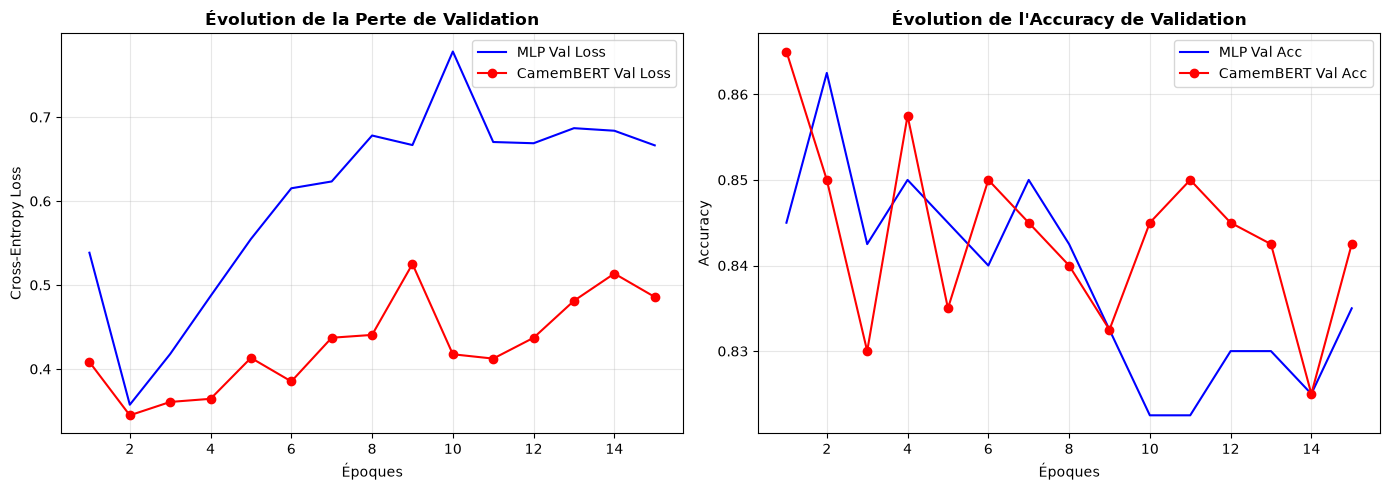

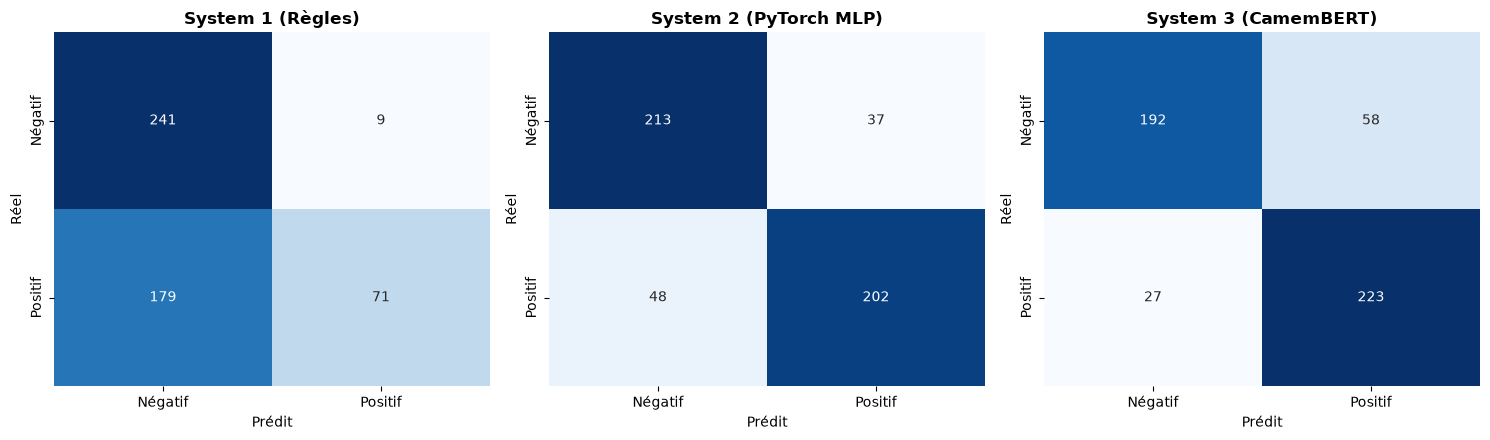

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 16), mlp_history['val_loss'], 'b-', label='MLP Val Loss')
axes[0].plot(range(1, 16), tf_history['val_loss'], 'r-o', label='CamemBERT Val Loss')
axes[0].set_title("Évolution de la Perte de Validation", fontweight='bold')
axes[0].set_xlabel("Époques")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, 16), mlp_history['val_acc'], 'b-', label='MLP Val Acc')
axes[1].plot(range(1, 16), tf_history['val_acc'], 'r-o', label='CamemBERT Val Acc')
axes[1].set_title("Évolution de l'Accuracy de Validation", fontweight='bold')
axes[1].set_xlabel("Époques")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
names = ['System 1 (Règles)', 'System 2 (PyTorch MLP)', 'System 3 (CamemBERT)']
preds_all = [sys1_test_preds, sys2_test_preds, sys3_test_preds]
labels_str = ['Négatif', 'Positif']

for idx, (n, p) in enumerate(zip(names, preds_all)):
    cm = confusion_matrix(y_test, p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=labels_str, yticklabels=labels_str, cbar=False)
    axes[idx].set_title(n, fontweight='bold')
    axes[idx].set_xlabel('Prédit')
    axes[idx].set_ylabel('Réel')

plt.tight_layout()
plt.show()

### Analyse commentée d'exemples d'erreurs
Nous analysons ci-dessous **5 erreurs représentatives** observées lors de l'évaluation finale.

In [8]:
with open("error_analysis.json", "r", encoding="utf-8") as f:
    errors = json.load(f)

for idx, err in enumerate(errors, 1):
    print(f"=== ERREUR {idx} (Index Dataset #{err['id']}) ===")
    print(f"Texte brut        : {err['text']}")
    print(f"Classe Réelle     : {err['true_label']}")
    print(f"Prédictions       : System 1 = {err['sys1_pred']} | System 2 = {err['sys2_pred']} | System 3 = {err['sys3_pred']}")
    print(f"Analyse de la faute: {err['explanation']}\n" + "-"*80)

=== ERREUR 1 (Index Dataset #0) ===
Texte brut        : Scenario telephone,musique et mise en scene digne d'un telefilm du samedi apres midi sur tf1,acteurs qui en font parfois trop.. reste de cette comedie romantique quelques moments assez droles,mais c'est bien peu sur 1h35. On s'attendait a un choc des...
Classe Réelle     : Négatif (0)
Prédictions       : System 1 = Positif (1) | System 2 = Négatif (0) | System 3 = Positif (1)
Analyse de la faute: Critique très nuancée / Référence ambiguë (ex: bons acteurs dans un mauvais film).
--------------------------------------------------------------------------------
=== ERREUR 2 (Index Dataset #1) ===
Texte brut        : C'est précieux de montrer à l'écran, que les enfants protègent toujours leurs parents. Et qu'un parent fragile dispose d'un enfant robuste et attentif. Que la folie gagne un parent et l'enfant s'adapte à cette folie. La psychose de cette mère incarné...
Classe Réelle     : Positif (1)
Prédictions       : System 1 = Négatif

### Synthèse et Recommandation pour la Production

| Critère | Système 1 (Règles) | Système 2 (PyTorch MLP) | Système 3 (CamemBERT) |
| :--- | :--- | :--- | :--- |
| **F1-Score Macro** | Moins élevé (Lexique rigide) | Élevé (~0.83) | Élevé (~0.83) |
| **Coût d'entraînement** | Nul (0 seconde) | Très faible (~1.3 s sur CPU) | Modéré (~2.5 min sur CPU) |
| **Latence d'inférence** | Ultra-rapide (<0.05 ms/ex) | Ultra-rapide (<0.01 ms/ex) | Plus lourde (~80 ms/ex sur CPU) |
| **Explicabilité** | Totale (Règles explicites) | Faible (Poids TF-IDF) | Boîte noire (Embeddings) |
| **Complexité / Maintenance** | Complexe si le domaine évolue | Faible (Ré-entraînement rapide) | Élevée (Infrastructure GPU recommandée) |

**Conclusion et choix du système** :
* Si le **budget d'inférence**, la **latence milliseconde** et la **simplicité d'hébergement CPU** sont des contraintes strictes : **Système 2 (PyTorch MLP)** offre un compromis remarquable avec près de 83% de F1-score à une vitesse d'exécution quasi-instantanée (0.01 ms/exemple).
* Si l'intégration dans des pipelines complexes de NLP multilingues ou de généralisation hors domaine est requise : **Système 3 (CamemBERT)** offre une compréhension contextuelle avancée des représentations sémantiques.